# Intro 

## Docs
Tickster API: https://md.xd.drw/tickster

Tickster Authentication: https://tickster.xd.drw/#auth-browser

General XD Docs: marketdata/

## Walk Through Bare-Bones Repo

In [1]:
from sample_repo.hello_world import say_hello
say_hello()

Hello World


## Won't need nest_asyncio for python > 3.6

In [2]:
import nest_asyncio
nest_asyncio.apply()

## Set up credentials the right way with a file

In [3]:
import importlib
from sample_repo import credentials
importlib.reload(credentials)

<module 'sample_repo.credentials' from '/home/alxiao/src/Week-5-Derivatives-Risk-Trading-2022-/OrdersCLOBOrderFlow(AlexXiao)/sample_repo/credentials.py'>

In [4]:
Token = credentials.get_xd_credentials()

## Code From Webworm Demo

https://webworm.xd.drw/?alhb5tv2

Here Alex shows how to get code from webworm to pull trades data for GCQ2 on 2022-07-05

## Adjust Webworm Code
Python code generated by WebWorm to access book data for GCQ2

Uses Tickster3 library. See: https://docs.xd.drw/tickster3/

```python
import asyncio
from tickster3.client import SymbolSearch, Tickster
from tickster3.query import TickSourceQuery
from tickster3.constants import Index

async def stream():
    async with SymbolSearch('webworm.codegen') as search, Tickster('webworm.codegen') as tickster:
        query = TickSourceQuery()
        query.add_exchange('CME')
        query.add_spec('MDP3_MBO')
        query.add_channel('360')
        query.add_symbol('GCQ2')
        query.add_date('2022-07-05'),

        source = await search.single_source(query=query)

        initial_time = 1656970200000000000
        trade_window = 2000000000
        start_time = initial_time - trade_window
        end_time = initial_time + 1

        snapshots = await tickster.snapshots(source=source, times=[initial_time], levels=5)
        async for timestamp, book in snapshots:
            print('Timestamp: %s' % timestamp)
            print('Top Ask: %s' % book.ask.top_level())
            print('Top Bid: %s' % book.bid.top_level())

        trades = await tickster.events(source=source, index=Index.TRADE, start=start_time, end=end_time)
        async for trade in trades:
            print(trade)

if __name__ == '__main__':
    asyncio.run(stream())
```

In [5]:
import asyncio
import numpy as np

from tickster3.client import SymbolSearch, Tickster
from tickster3.query import TickSourceQuery
from tickster3.constants import Index

usage = 'education2022'

async def stream():
    fields = None
    out = []
    
    async with SymbolSearch(usage, token=Token) as search, Tickster(usage, token=Token) as tickster:
        query = TickSourceQuery()
        query.add_exchange('CME')
        query.add_spec('MDP3_MBO')
        query.add_channel('360')
        query.add_symbol('GCQ2')
        query.add_date('2022-07-05')

        source = await search.single_source(query=query)

        trades = await tickster.events(source=source, index=Index.TRADE)
        
        async for trade in trades:
            if fields is None:
                fields = np.dtype(trade).names
            out.append(trade.tolist())
        
    return fields, out

fields, trades = asyncio.run(stream())

In [6]:
import pandas as pd
df = pd.DataFrame(trades, columns=fields)
df = df.drop([c for c in df.columns if c.startswith('has_')], axis=1)
df.to_hdf('data/gc_data.hdf', key='trades')
df

/home/alxiao/miniconda3/envs/systools_env/lib/python3.6/site-packages/pandas/core/generic.py:2505: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->bytes,key->block1_values] [items->Index(['event', 'side', 'aggressed_side', 'status', 'trading_status',
       'exchange_trading_status'],
      dtype='object')]

  encoding=encoding,


,epoch,msg_seq_num,tick_seq,event,id,side,px,raw_px,qty,raw_qty,...,trading_status,exchange_trading_status,order_id,trade_summary_id,transact_time,match_event_indicator,security_trading_event,sending_time,md_trade_entry_id,indexes
0,1656972000094899627,3369281,34901,b'T',0,b'',1808.3,18083.0,5,5.0,...,b'',b'',0,1,1656972000000000000,0,0,1656972000094881624,1574861,3
1,1656972000128953675,3369487,134601,b'T',0,b'',1808.8,18088.0,1,1.0,...,b'',b'',0,10,1656972000127438895,1,0,1656972000128937080,1574872,3
2,1656972000151100021,3369552,134736,b'T',0,b'',1808.5,18085.0,2,2.0,...,b'',b'',0,12,1656972000150803421,1,0,1656972000151080079,1574874,3
3,1656972000155840480,3369563,134765,b'T',0,b'',1808.9,18089.0,1,1.0,...,b'',b'',0,14,1656972000155624851,1,0,1656972000155820646,1574876,3
4,1656972000606727053,3370359,136695,b'T',0,b'',1808.7,18087.0,1,1.0,...,b'',b'',0,18,1656972000606452735,1,0,1656972000606708215,1574882,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93305,1657054795105718590,12759522,26037287,b'T',0,b'',1763.7,17637.0,4,4.0,...,b'',b'',0,216567,1657054795105541945,1,0,1657054795105695909,15306180,3
93306,1657054795105915781,12759524,26037295,b'T',0,b'',1763.7,17637.0,4,4.0,...,b'',b'',0,216568,1657054795105722979,1,0,1657054795105895982,15306181,3
93307,1657054795106756663,12759572,26037404,b'T',0,b'',1763.8,17638.0,1,1.0,...,b'',b'',0,216569,1657054795106523967,1,0,1657054795106739825,15306182,3
93308,1657054795183241879,12759645,26037570,b'T',0,b'',1763.9,17639.0,1,1.0,...,b'',b'',0,216572,1657054795182907195,1,0,1657054795183220394,15306187,3


In [20]:
# Use this as backup in case tickster is slow
import pandas as pd
df = pd.read_hdf('data/gc_data.hdf')

# 1. Find Biggest Sweep

Use the data frame from above, find the largest sweep due to a single aggressor.

Pull up the example in webworm.

In [21]:
total_traded = df.groupby('transact_time').agg({'epoch': 'first', 'qty': 'sum', 'px': 'nunique'}).sort_values('qty')
total_traded.tail()

,epoch,qty,px
transact_time,,,
1657029900330618911,1657029900332393487,322,17
1657034920497754505,1657034920499443134,327,8
1657030165878980561,1657030165880955603,355,25
1657029617748452117,1657029617752701040,569,34
1657029600039174259,1657029600043715581,678,34


# 2. Fit a power law to quantities

Recall that Avellandeda and Stoikov assume order size follows a power law
$$f^Q(x) = C x^{-1-\alpha}$$

a. Assess how reasonable this is with a plot and a linear fit.

b. What are the parameters for $C$ and $\alpha$?

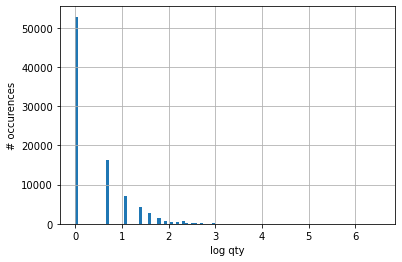

In [9]:
import numpy as np

total_traded['log_qty'] = total_traded.qty_sum.apply(np.log)
ax = total_traded.log_qty.hist(bins=100)
# ax.set_yscale('log')
ax.set_ylabel('# occurences')
ax.set_xlabel('log qty');

In [10]:
counts, bins = np.histogram(total_traded.log_qty, bins=100)
qty_dist = (
    pd.Series(counts, index=bins[:-1])
    .replace(0, np.nan)
    .dropna()
    .div(total_traded.shape[0])
    .apply(np.log)
    .rename('log_likelihood')
)
qty_dist.index.names = 'log_qty',
qty_dist = qty_dist.reset_index()

In [11]:
import statsmodels.api as sm

x = sm.add_constant(qty_dist.reset_index().log_qty)
model = sm.OLS(qty_dist.log_likelihood, x)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         log_likelihood   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     428.9
Date:                Mon, 08 Aug 2022   Prob (F-statistic):           2.34e-27
Time:                        21:31:12   Log-Likelihood:                -73.654
No. Observations:                  56   AIC:                             151.3
Df Residuals:                      54   BIC:                             155.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7447      0.335     -5.206      0.000      -2.417      -1.073
log_qty       -1.8203      0.088    -20.710      0.000      -1.996      -1.644
==============================================================================
Omnibus:                        1.798   Durbin-Watson:                   0.914
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.738
Skew:                           0.351   Prob(JB):                        0.419
Kurtosis:                       2.499   Cond. No.                         11.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

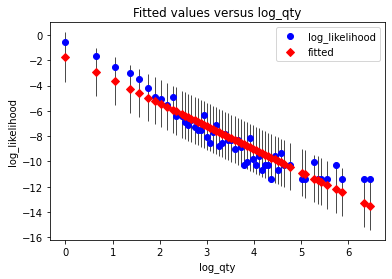

In [12]:
sm.graphics.plot_fit(result, 'log_qty');

In [13]:
f'C: {np.exp(result.params[0]):.4f} alpha: {result.params[1] * -1 -1:.4f}'

'C: 0.1747 alpha: 0.8203'

In [14]:
import statsmodels.api as sm

x = sm.add_constant(qty_dist.reset_index().log_qty)
model = sm.WLS(qty_dist.log_likelihood, x, weights=qty_dist.log_likelihood.apply(np.exp).apply(np.sqrt))
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:         log_likelihood   R-squared:                       0.973
Model:                            WLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1982.
Date:                Mon, 08 Aug 2022   Prob (F-statistic):           3.01e-44
Time:                        21:31:13   Log-Likelihood:                -68.340
No. Observations:                  56   AIC:                             140.7
Df Residuals:                      54   BIC:                             144.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4092      0.093     -4.401      0.000      -0.596      -0.223
log_qty       -2.1993      0.049    -44.516      0.000      -2.298      -2.100
==============================================================================
Omnibus:                        5.878   Durbin-Watson:                   1.102
Prob(Omnibus):                  0.053   Jarque-Bera (JB):                3.267
Skew:                           0.377   Prob(JB):                        0.195
Kurtosis:                       2.087   Cond. No.                         3.29
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

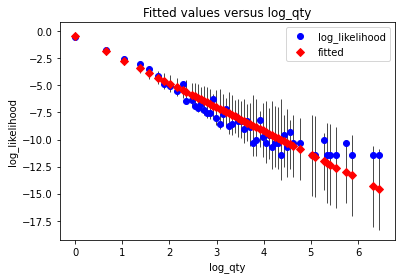

In [15]:
sm.graphics.plot_fit(result, 'log_qty');

In [16]:
f'C: {np.exp(result.params[0]):.4f} alpha: {result.params[1] * -1 -1:.4f}'

'C: 0.6642 alpha: 1.1993'

# 3. In Trade time, fit a market impact model for 20 trades into the future

First aggregate trades by the same transact time observed. Then create a prediction on the change in price based on total qty traded (signed by aggressed side)

For reference price, use min of the levels traded if the offers are aggressed and the max if the bids are aggressed.

In [34]:
total_traded = df.groupby('transact_time').agg({'qty': 'sum', 'aggressed_side': 'last', 'px': ['min', 'max']})
total_traded.columns = ['_'.join(col).strip() for col in total_traded.columns.values]
total_traded

,qty_sum,aggressed_side_last,px_min,px_max
transact_time,,,,
1656972000000000000,5,b'',1808.3,1808.3
1656972000127438895,1,b'A',1808.8,1808.8
1656972000150803421,2,b'B',1808.5,1808.5
1656972000155624851,1,b'A',1808.9,1808.9
1656972000606452735,1,b'A',1808.7,1808.7
...,...,...,...,...
1657054795105541945,4,b'A',1763.7,1763.7
1657054795105722979,4,b'A',1763.7,1763.7
1657054795106523967,1,b'B',1763.8,1763.8


In [37]:
side = total_traded.aggressed_side_last
total_traded['ref_px'] = np.where(side.eq(b''), np.nan, np.where(side.eq(b'A'), total_traded.px_min, total_traded.px_max))

In [40]:
total_traded = total_traded.dropna()

In [46]:
total_traded['px_change'] = total_traded.ref_px.diff(20)
total_traded['signed_qty'] = total_traded.aggressed_side_last.map({b'A': 1, b'B': -1}) * total_traded.qty_sum

/home/alxiao/miniconda3/envs/systools_env/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/home/alxiao/miniconda3/envs/systools_env/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


<AxesSubplot:xlabel='signed_qty', ylabel='px_change'>

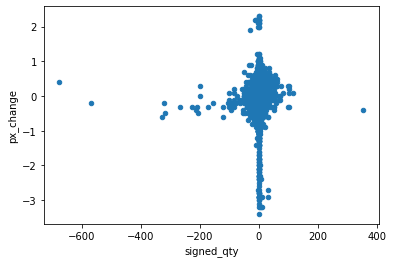

In [47]:
total_traded.plot.scatter(x='signed_qty', y='px_change')

In [54]:
x = total_traded[total_traded.px_change.lt(-2)].copy()
x['ct_time'] = pd.to_datetime(x.index).tz_localize('UTC').tz_convert('US/Central')

In [55]:
x

,qty_sum,aggressed_side_last,px_min,px_max,ref_px,px_change,signed_qty,ct_time
transact_time,,,,,,,,
1657028841339851887,1,b'A',1786.2,1786.2,1786.2,-2.3,1,2022-07-05 08:47:21.339851887-05:00
1657028841339852385,1,b'A',1786.2,1786.2,1786.2,-2.3,1,2022-07-05 08:47:21.339852385-05:00
1657028841340382769,1,b'A',1786.2,1786.2,1786.2,-2.4,1,2022-07-05 08:47:21.340382769-05:00
1657028841340395811,2,b'A',1786.2,1786.2,1786.2,-2.4,2,2022-07-05 08:47:21.340395811-05:00
1657028841341998291,1,b'A',1786.2,1786.2,1786.2,-2.3,1,2022-07-05 08:47:21.341998291-05:00
1657028841341999767,1,b'A',1786.2,1786.2,1786.2,-2.3,1,2022-07-05 08:47:21.341999767-05:00
1657028841342011961,2,b'A',1786.2,1786.2,1786.2,-2.2,2,2022-07-05 08:47:21.342011961-05:00
1657028841342013977,2,b'A',1786.2,1786.2,1786.2,-2.2,2,2022-07-05 08:47:21.342013977-05:00
1657028841342054541,1,b'A',1786.2,1786.2,1786.2,-2.1,1,2022-07-05 08:47:21.342054541-05:00
